#TASK 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#WINE QUALITY PREDICTION

In [2]:
df = pd.read_csv("WineQT.csv", sep=";")

df.head()

,"fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id"
0,"7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0...."
1,"7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.2,0...."
2,"7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0..."
3,"11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,..."
4,"7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0...."


##INITIAL INSPECTION

In [10]:
df = pd.read_csv("WineQT.csv", sep=",")

In [11]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1143, 13)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id         

### Observation

The dataset contains 1,143 wine samples and 13 columns. It includes 11 physicochemical features, along with the quality score and an ID column. All chemical features are stored as numerical values, making them suitable for statistical analysis and machine learning. No missing values were found in any column, so missing-value treatment is not required at this stage.

##DESCRIPTIVE STATISTICS

In [12]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [13]:
print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
fixed acidity             8.311111
volatile acidity          0.531339
citric acid               0.268364
residual sugar            2.532152
chlorides                 0.086933
free sulfur dioxide      15.615486
total sulfur dioxide     45.914698
density                   0.996730
pH                        3.311015
sulphates                 0.657708
alcohol                  10.442111
quality                   5.657043
Id                      804.969379
dtype: float64

Median:
fixed acidity             7.90000
volatile acidity          0.52000
citric acid               0.25000
residual sugar            2.20000
chlorides                 0.07900
free sulfur dioxide      13.00000
total sulfur dioxide     37.00000
density                   0.99668
pH                        3.31000
sulphates                 0.62000
alcohol                  10.20000
quality                   6.00000
Id                      794.00000
dtype: float64

Standard Deviation:
fixed acidity             1.747595
vo

### Observation

The average wine quality score is approximately 5.66, while the median is 6, indicating that the dataset is concentrated around the medium-quality range. Alcohol has an average value of approximately 10.44%, with a standard deviation of 1.08, showing moderate variation across the samples.

Free sulfur dioxide and total sulfur dioxide show relatively high variability, with standard deviations of approximately 10.25 and 32.78 respectively. This indicates considerable differences in these chemical properties among the wine samples. The standard deviations of pH and density are relatively small, suggesting that these measurements vary less across the dataset.

##QUALITY SCORE DISTRIBUTION

In [16]:
print("Quality Score Distribution:")
print(df['quality'].value_counts().sort_index())

Quality Score Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


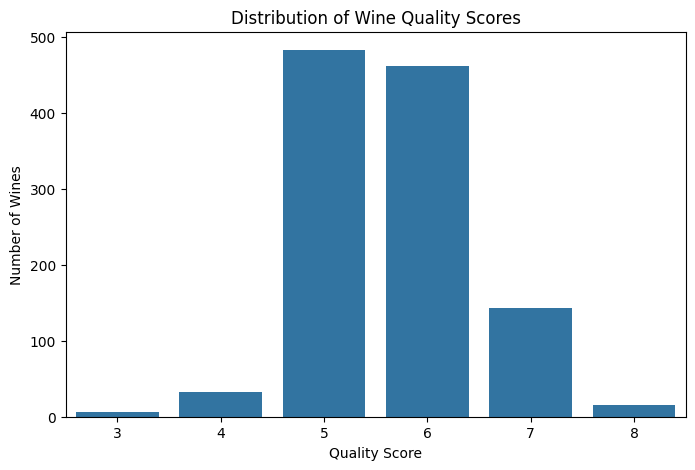

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x='quality', data=df)

plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')

plt.show()

### Observation

The wine quality scores are highly imbalanced. Most wine samples have quality scores of 5 (483 samples) and 6 (462 samples), while very few samples have quality scores of 3 (6 samples) and 8 (16 samples). Quality scores of 4 and 7 are also less represented compared with scores 5 and 6.

This imbalance may affect the classification models because the models have much more training data for the middle-quality wines than for the very low- and very high-quality wines. Therefore, the minority classes may be harder for the models to predict correctly.

##CHEMICAL FEATURE DISTRIBUTION

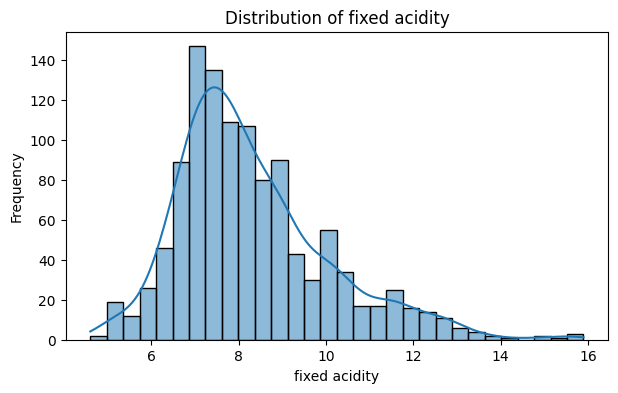

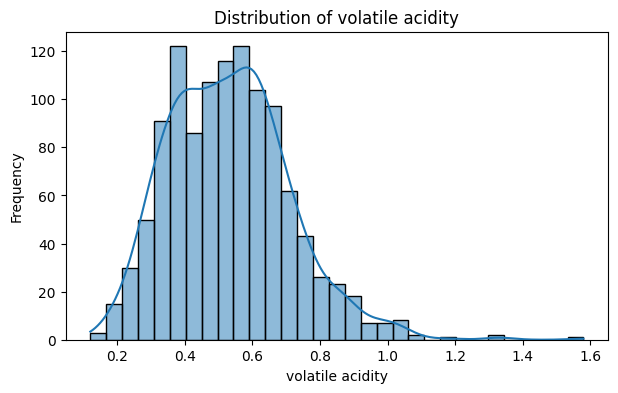

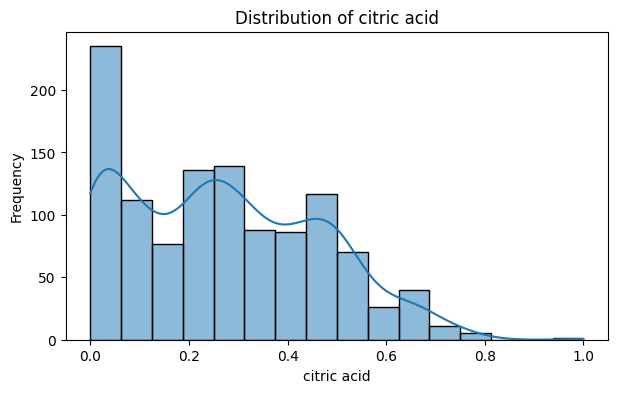

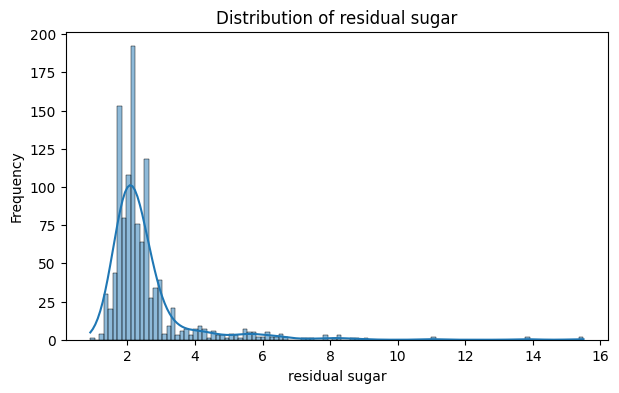

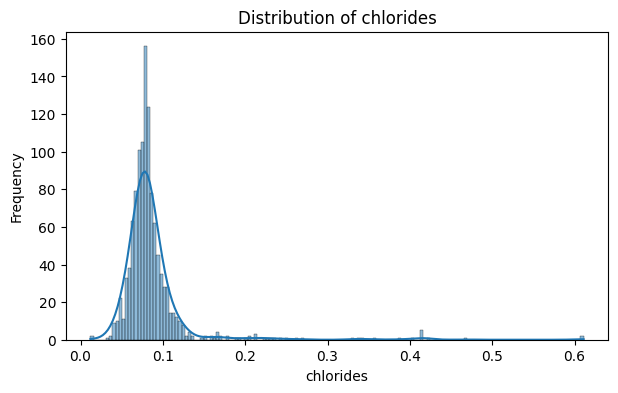

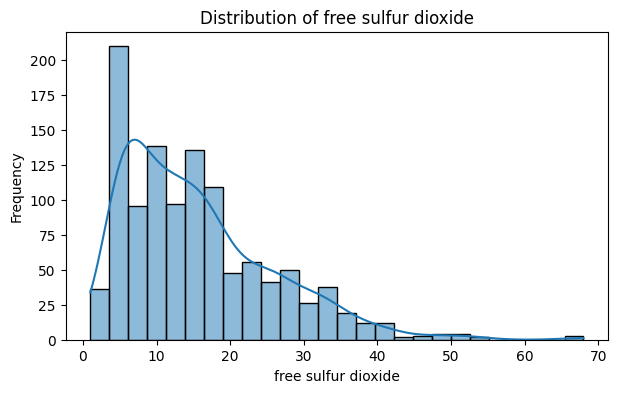

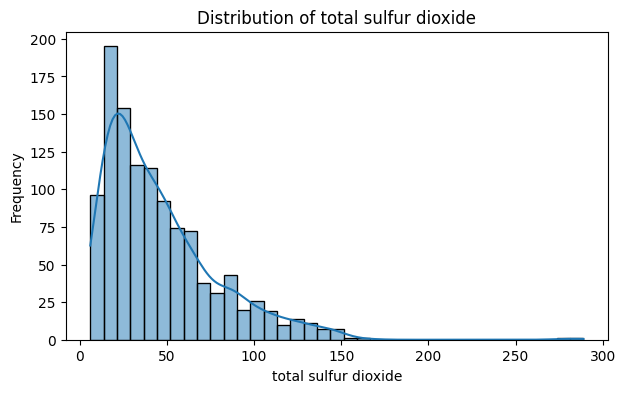

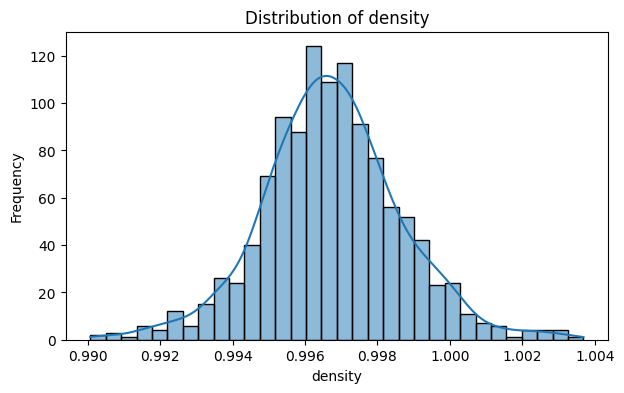

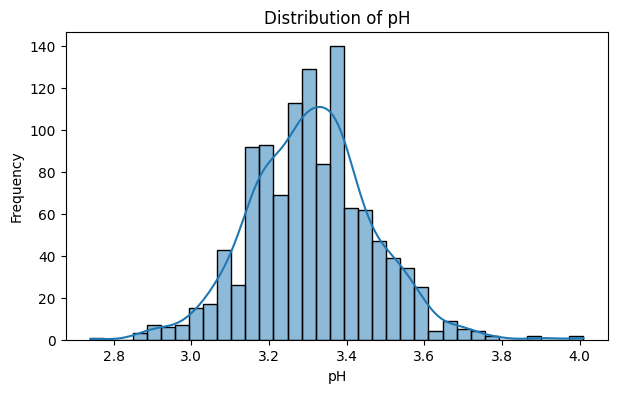

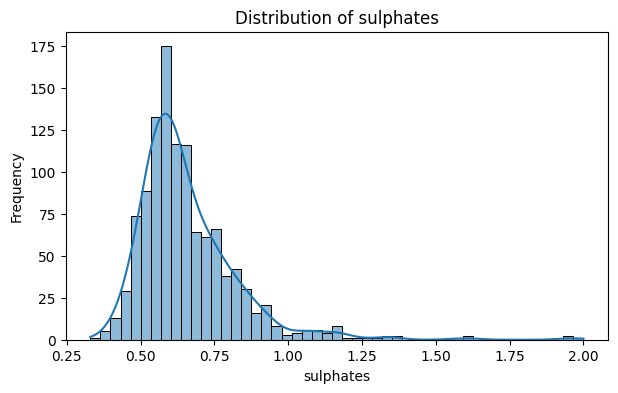

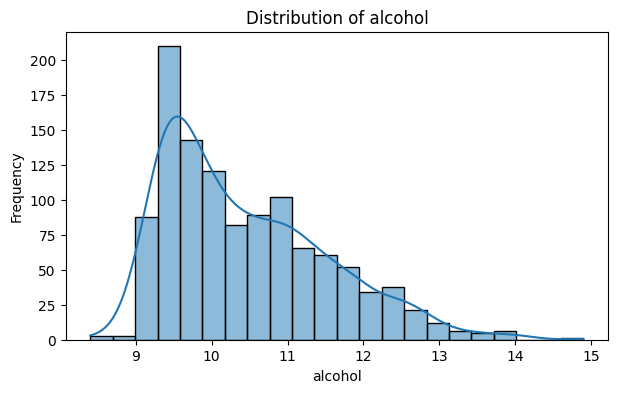

In [17]:
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

for feature in features:
    plt.figure(figsize=(7,4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

### Observation

The chemical features show different distributions and ranges across the wine samples. Several variables are not perfectly symmetric and show some degree of skewness, indicating that certain chemical measurements have a concentration of values within particular ranges. Features such as free sulfur dioxide and total sulfur dioxide show wider variation compared with variables such as density and pH. These differences in feature distributions and scales are important to consider during preprocessing and machine learning.

##CORRELATION HEATMAP

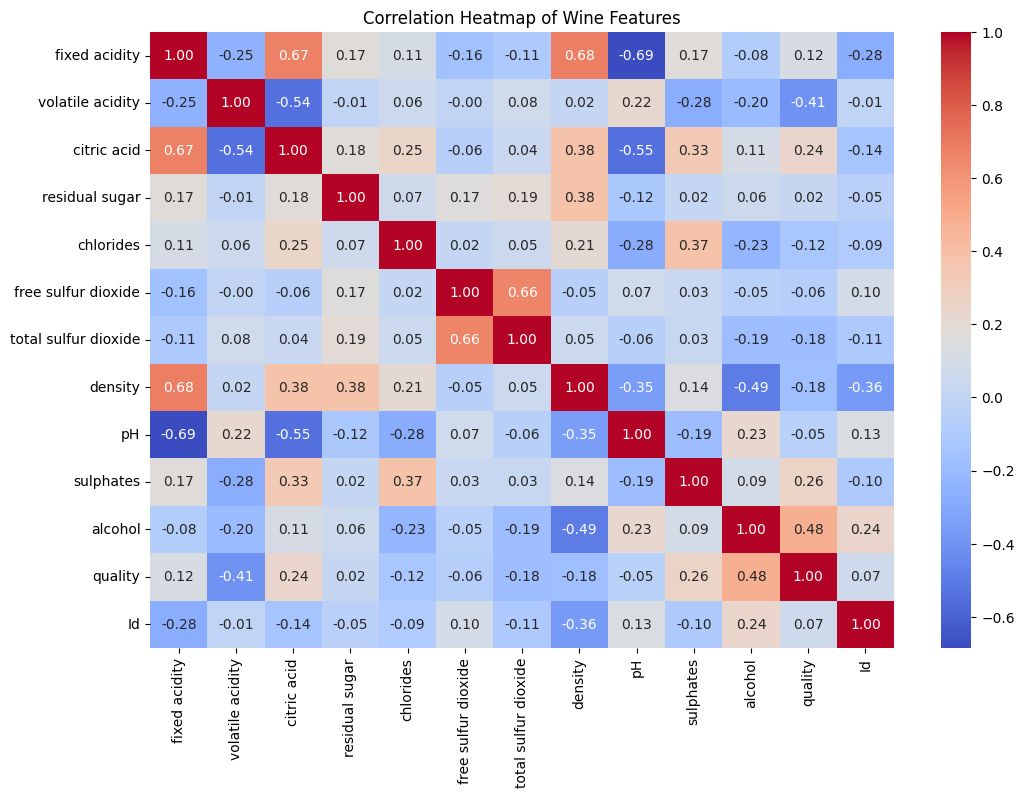

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Wine Features')

plt.show()

### Observation

The correlation heatmap shows that the chemical features have different levels of relationships with each other and with wine quality. Alcohol shows a positive relationship with wine quality, while volatile acidity shows a negative relationship with quality. Some chemical variables also have stronger relationships with one another, such as free sulfur dioxide and total sulfur dioxide.

Overall, the correlations indicate that wine quality is influenced by multiple physicochemical properties rather than a single feature. The relationships observed in the heatmap can help identify potentially important features for the machine learning models.

##CREATE QUALITY GROUPS

In [19]:
def quality_group(quality):
    if quality <= 4:
        return 'Low'
    elif quality <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_group'] = df['quality'].apply(quality_group)

print(df['quality_group'].value_counts())

quality_group
Medium    945
High      159
Low        39
Name: count, dtype: int64


###VISUALIZING GROUP DATA

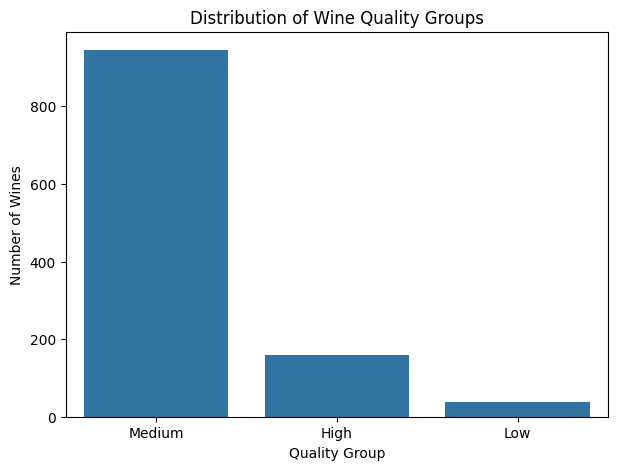

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='quality_group',
    data=df
)

plt.title('Distribution of Wine Quality Groups')
plt.xlabel('Quality Group')
plt.ylabel('Number of Wines')

plt.show()

### Observation

The original wine quality scores were grouped into three categories: Low (3–4), Medium (5–6), and High (7–8). The Medium category contains the majority of the wine samples, while the Low and High categories contain considerably fewer observations. This grouping simplifies the classification problem while retaining meaningful differences between low-, medium-, and high-quality wines.

##FEATURES FOR MACHINE LEARNING

In [21]:
X = df.drop(columns=['quality', 'quality_group', 'Id'])
y = df['quality_group']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality_group


### Observation

The physicochemical properties of the wine are selected as the predictor variables, while the newly created quality group is used as the target variable. The original quality score and ID column are excluded from the features to prevent target leakage and ensure that the ID does not influence the model.

##TRAIN OR TEST SPLIT

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (914, 11)
Testing set: (229, 11)

Training class distribution:
quality_group
Medium    756
High      127
Low        31
Name: count, dtype: int64

Testing class distribution:
quality_group
Medium    189
High       32
Low         8
Name: count, dtype: int64


### Observation

The dataset was divided into 914 training samples and 229 testing samples, representing an 80:20 split. Stratification was used to preserve the class distribution in both sets. The Medium-quality group remains the largest class in both the training and testing data, while the Low-quality group has the fewest samples. This class imbalance should be considered when interpreting the classification results.

##STANDARDIZATION

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data standardized successfully.")
print("Testing data standardized successfully.")

Training data standardized successfully.
Testing data standardized successfully.


### Observation

Standardization was applied to the predictor variables so that features with different numerical scales could contribute more appropriately to the machine learning models. The scaler was fitted only on the training data and then applied to the testing data to avoid data leakage.

##RANDOM FOREST TEST

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8602620087336245


### Observation

The Random Forest classifier achieved an accuracy of approximately 86.03% on the testing dataset. This indicates that the model correctly classified most of the unseen wine samples into their respective quality groups. However, accuracy alone may not fully represent model performance because the quality groups are imbalanced, so precision, recall, F1-score, and the confusion matrix should also be considered.

###CLASSIFICATION REPORT

In [25]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.53      0.60        32
         Low       0.00      0.00      0.00         8
      Medium       0.89      0.95      0.92       189

    accuracy                           0.86       229
   macro avg       0.52      0.49      0.50       229
weighted avg       0.83      0.86      0.84       229



###CONFUSION MATRIX

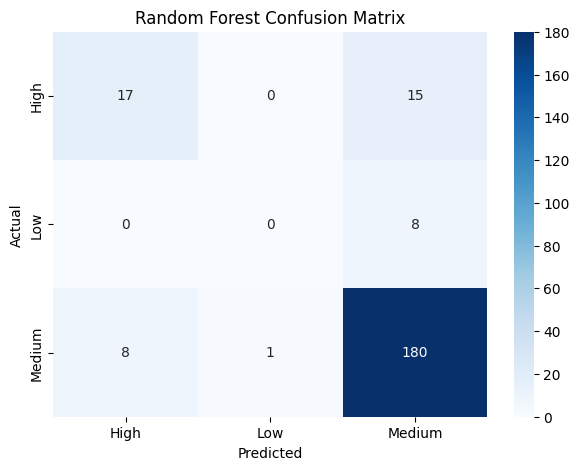

In [26]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Observation

The confusion matrix shows that the Random Forest model performs well in identifying Medium-quality wines, correctly classifying 180 of the 189 Medium samples. It also correctly identifies 17 of the 32 High-quality wines. However, the model does not correctly classify any of the 8 Low-quality wines, which are all predicted as Medium. This indicates that the model is strongly influenced by the majority Medium class and has difficulty identifying the minority Low-quality class.

##SGD CLASSIFIER

In [28]:
sgd_model = SGDClassifier(random_state=42)

sgd_model.fit(X_train_scaled, y_train)

sgd_pred = sgd_model.predict(X_test_scaled)

sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", sgd_accuracy)

SGD Accuracy: 0.8209606986899564


### Observation

The SGD classifier achieved an accuracy of approximately 82.10% on the testing dataset. This indicates that the model correctly classified most of the unseen wine samples, but its overall accuracy was lower than the Random Forest model's accuracy of 86.03%. Since the quality groups are imbalanced, the classification report and confusion matrix will also be examined to understand how well SGD performs for each quality group.

##SGD CLASSIFICATION REPORT

In [29]:
print("SGD Classification Report:")
print(classification_report(y_test, sgd_pred))

SGD Classification Report:
              precision    recall  f1-score   support

        High       0.48      0.44      0.46        32
         Low       0.00      0.00      0.00         8
      Medium       0.87      0.92      0.89       189

    accuracy                           0.82       229
   macro avg       0.45      0.45      0.45       229
weighted avg       0.79      0.82      0.80       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


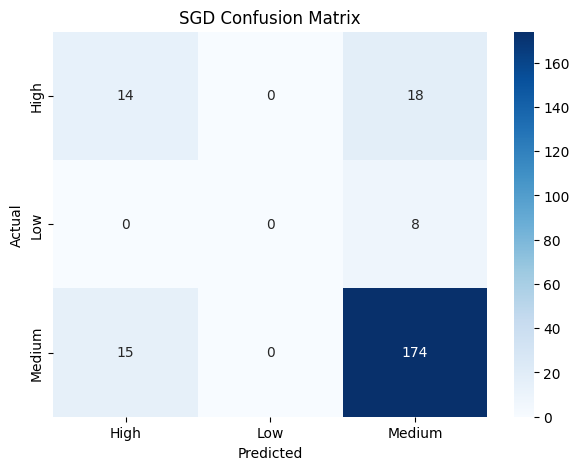

In [30]:
cm = confusion_matrix(y_test, sgd_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.title('SGD Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Observation

The SGD classifier achieved an accuracy of approximately 82.10% on the testing dataset. It correctly classified 188 out of 229 test samples. The model performed well on the majority Medium class but struggled to identify the minority Low-quality class, with a recall of 0.00. Its overall accuracy was lower than Random Forest's 86.03% and SVC's 84.28%.

##SVC

In [31]:
svc_model = SVC(random_state=42)

svc_model.fit(X_train_scaled, y_train)

svc_pred = svc_model.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", svc_accuracy)

SVC Accuracy: 0.8427947598253275


### Observation

The SVC classifier achieved an accuracy of approximately 84.28% on the testing dataset. It correctly classified 193 out of 229 test samples. The model performed strongly on the Medium-quality class but struggled with the minority Low-quality class, which had a recall of 0.00. It also correctly identified 8 of the 32 High-quality wines, while 24 High-quality wines were classified as Medium.

##SVC CLASSIFICATION REPORT

In [32]:
print("SVC Classification Report:")
print(classification_report(y_test, svc_pred))

SVC Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.25      0.36        32
         Low       0.00      0.00      0.00         8
      Medium       0.85      0.98      0.91       189

    accuracy                           0.84       229
   macro avg       0.51      0.41      0.42       229
weighted avg       0.80      0.84      0.80       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


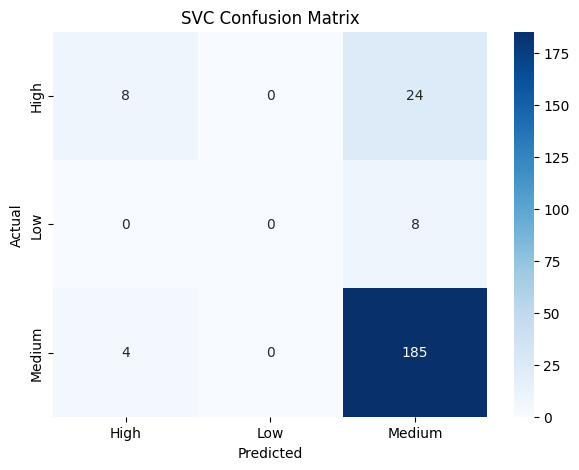

In [33]:
cm = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Low', 'Medium'],
    yticklabels=['High', 'Low', 'Medium']
)

plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Observation

The SVC classifier correctly classified 201 out of 229 test samples. It correctly identified all 8 Low-quality wines and 185 of the 189 Medium-quality wines. However, the model had difficulty identifying High-quality wines, correctly classifying only 8 of the 32 High-quality samples, while 24 were classified as Medium. Overall, SVC performed better than SGD in terms of accuracy but lower than Random Forest.

##MODEL COMPARISON

In [35]:
rf_accuracy = 0.8602620087336245
sgd_accuracy = 0.8209606986899564
svc_accuracy = 0.8427947598253275

In [36]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

print(comparison)

           Model  Accuracy
0  Random Forest  0.860262
1            SGD  0.820961
2            SVC  0.842795


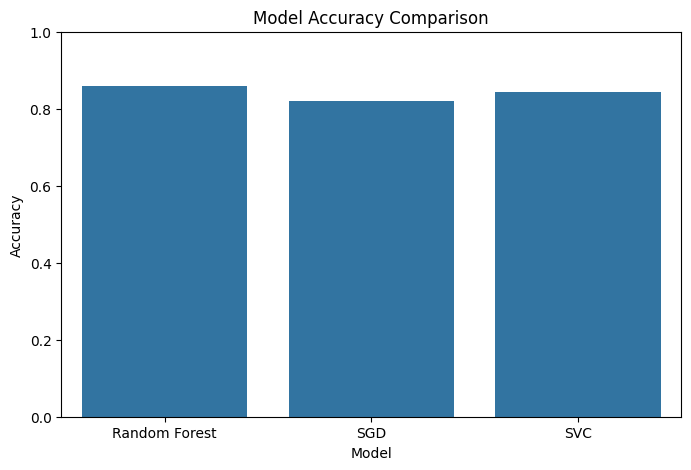

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.show()

### Observation

Among the three classification models, Random Forest achieved the highest accuracy of 86.03%, followed by SVC with 84.28% and SGD with 82.10%. Therefore, Random Forest provided the best overall accuracy on the testing dataset. However, because the wine quality groups are imbalanced, model selection should also consider class-wise precision, recall, and F1-score rather than accuracy alone.

##RANDOM FOREST FEATURE IMPORTANCE

In [38]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

alcohol                 0.152932
volatile acidity        0.126291
sulphates               0.102525
density                 0.096763
citric acid             0.087880
chlorides               0.086648
fixed acidity           0.081416
residual sugar          0.074461
total sulfur dioxide    0.071365
pH                      0.063891
free sulfur dioxide     0.055828
dtype: float64


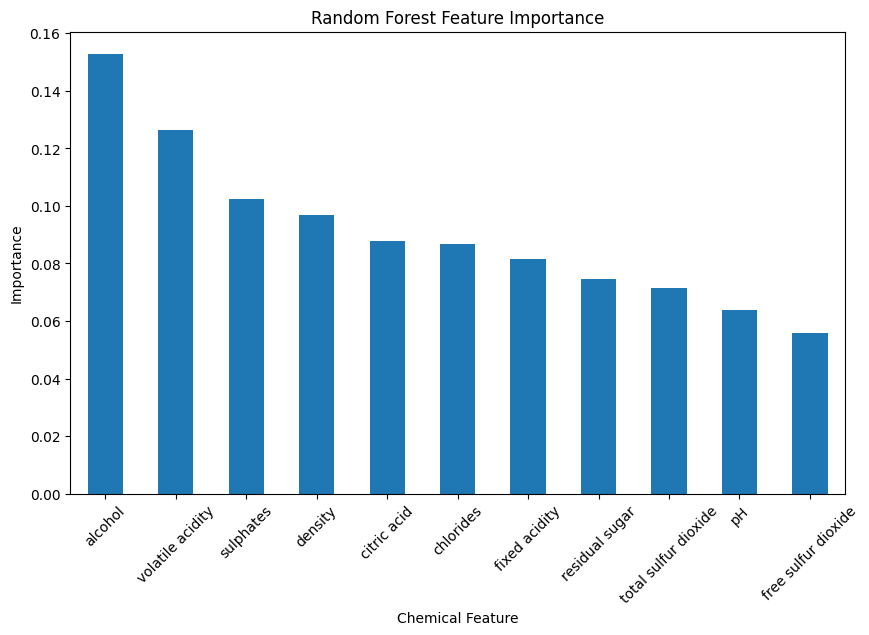

In [39]:
plt.figure(figsize=(10,6))

feature_importance.plot(kind='bar')

plt.title('Random Forest Feature Importance')
plt.xlabel('Chemical Feature')
plt.ylabel('Importance')

plt.xticks(rotation=45)

plt.show()

### Observation

The Random Forest feature-importance analysis shows that alcohol is the most influential feature for predicting wine quality, with an importance score of approximately 0.153. Volatile acidity is the second most important feature, followed by sulphates and density. Free sulfur dioxide has the lowest importance among the features, with a score of approximately 0.056.

These results indicate that alcohol, volatile acidity, sulphates, and density contribute more strongly to the model's classification decisions than the other physicochemical properties in this dataset.

# Conclusion

This project used physicochemical properties of wine to predict wine quality using three classification algorithms: Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC).

The original quality scores were grouped into Low, Medium, and High categories to create a multiclass classification problem. The dataset showed significant class imbalance, with Medium-quality wines representing the majority of observations.

Among the three models, Random Forest achieved the highest accuracy of 86.03%, followed by SVC at 84.28% and SGD at 82.10%. Therefore, Random Forest provided the best overall accuracy on the testing dataset.

The Random Forest feature-importance analysis identified alcohol as the most influential feature, followed by volatile acidity, sulphates, and density.

However, the confusion matrices showed that the models have difficulty identifying some minority classes, particularly the Low and High quality groups. Therefore, accuracy alone should not be used to judge model performance.

## Recommendations

1. **Use Random Forest as the initial candidate model** because it achieved the highest overall accuracy of 86.03% among the three tested models.

2. **Collect more samples for minority quality groups**, especially Low and High quality wines, to improve the model's ability to recognize underrepresented classes.

3. **Focus on important chemical properties** such as alcohol, volatile acidity, sulphates, and density because they had the highest feature-importance scores in the Random Forest model.

4. **Evaluate models using precision, recall, and F1-score in addition to accuracy**, particularly because the dataset has an imbalanced class distribution.

5. **Test the selected model on additional unseen wine samples** before considering it for practical deployment.